## Load & Inspect a Tanager Scene

In [14]:
import h5py

data_path = "/Users/suvampatel/Documents/Tanager Open Data Competition - Methane Leak Attribution/data/raw/20250205_175845_00_4001_basic_radiance.h5"

with h5py.File(data_path, "r") as f:
    f.visit(lambda name: print(name))

HDFEOS
HDFEOS/ADDITIONAL
HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
HDFEOS/SWATHS
HDFEOS/SWATHS/HYP
HDFEOS/SWATHS/HYP/Data Fields
HDFEOS/SWATHS/HYP/Data Fields/beta_cirrus_mask
HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask
HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels
HDFEOS/SWATHS/HYP/Data Fields/sensor_azimuth
HDFEOS/SWATHS/HYP/Data Fields/sensor_to_ground_path_length
HDFEOS/SWATHS/HYP/Data Fields/sensor_zenith
HDFEOS/SWATHS/HYP/Data Fields/sun_azimuth
HDFEOS/SWATHS/HYP/Data Fields/sun_zenith
HDFEOS/SWATHS/HYP/Data Fields/toa_radiance
HDFEOS/SWATHS/HYP/Geolocation Fields
HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude
HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude
HDFEOS/SWATHS/HYP/Geolocation Fields/Time
HDFEOS INFORMATION
HDFEOS INFORMATION/StructMetadata.0


In [15]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def load_tanager_scene(filepath):
    """Load a Tanager HDF5 file into an xarray Dataset."""
    with h5py.File(filepath, "r") as f:
        
        toa = f["HDFEOS/SWATHS/HYP/Data Fields/toa_radiance"]
        radiance       = toa[:]                          # shape: (426, 432, 607) → (bands, lines, samples)
        wavelengths_nm = toa.attrs["wavelengths"]        # already in nm
        
        lat = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude"][:]
        lon = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude"][:]

    ds = xr.Dataset(
        {"radiance": (["band", "line", "sample"], radiance)},
        coords={
            "wavelength_nm": ("band", wavelengths_nm),
            "lat": (["line", "sample"], lat),
            "lon": (["line", "sample"], lon),
        }
    )
    return ds


def plot_rgb_quicklook(ds, out_path="../outputs/figures/quicklook_rgb.png"):
    """Plot a false-color RGB quicklook."""
    wl  = ds["wavelength_nm"].values
    rad = ds["radiance"].values   # (bands, lines, samples)

    r_idx = np.argmin(np.abs(wl - 650))
    g_idx = np.argmin(np.abs(wl - 550))
    b_idx = np.argmin(np.abs(wl - 450))

    rgb = np.stack([
        rad[r_idx, :, :],
        rad[g_idx, :, :],
        rad[b_idx, :, :]
    ], axis=-1)  # → (lines, samples, 3) for matplotlib

    # Normalize with 2%/98% percentile stretch for better contrast
    p2, p98 = np.percentile(rgb[rgb > 0], [2, 98])
    rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb)
    plt.title("Tanager RGB Quicklook (R:650nm G:550nm B:450nm)")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

In [16]:
data_path = "/Users/suvampatel/Documents/Tanager Open Data Competition - Methane Leak Attribution/data/raw/20250205_175845_00_4001_basic_radiance.h5"

with h5py.File(data_path, "r") as f:
    toa = f["HDFEOS/SWATHS/HYP/Data Fields/toa_radiance"]
    print("Shape:", toa.shape)
    print("Attributes:")
    for k, v in toa.attrs.items():
        print(f"  {k}: {v[:5] if hasattr(v, '__len__') else v}")


Shape: (426, 680, 607)
Attributes:
  Unit: W/(m^
  _FillValue: -9999.0
  applied_radiometric_coefficients: [0.24117877 0.19664247 0.12794702 0.10599381 0.0785861 ]
  applied_radiometric_coefficients_units: W/(m^
  fwhm: [5.39 5.42 5.45 5.48 5.52]
  fwhm_units: nm
  wavelengths: [376.44 381.41 386.38 391.35 396.32]
  wavelengths_units: nm


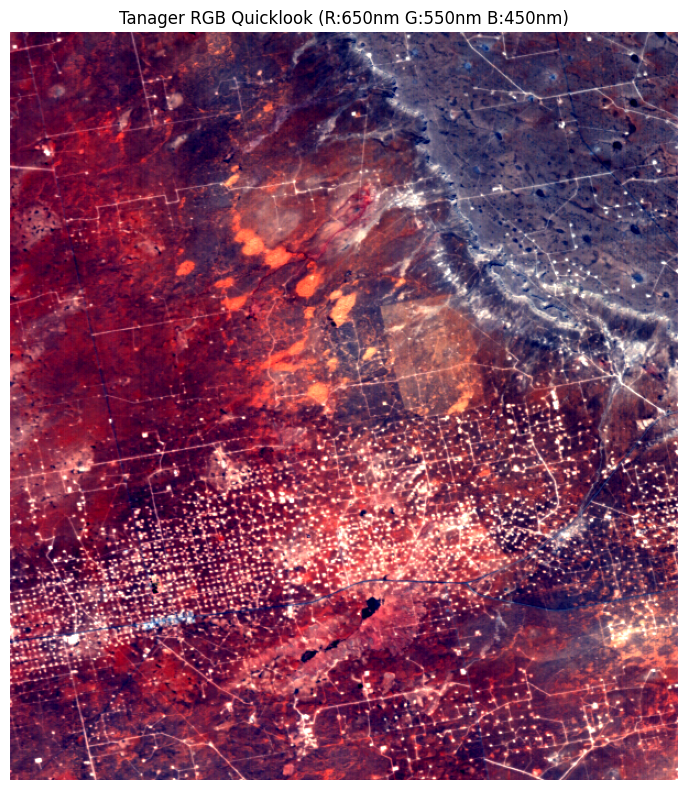

Saved: ../outputs/figures/quicklook_rgb.png


In [17]:
data_path = "/Users/suvampatel/Documents/Tanager Open Data Competition - Methane Leak Attribution/data/raw/20250205_175845_00_4001_basic_radiance.h5"

ds = load_tanager_scene(data_path)
plot_rgb_quicklook(ds)